<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/standards/standards_based_engineering_checks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standards-based gas-line and relief screening with NeqSim

This notebook turns early gas-line checks into a reproducible NeqSim workflow. It preserves
the original fluid definition, three design cases, velocity/pressure-drop screening, and
combined flags. It replaces the former placeholder pressure-gradient factor with a
compressible `PipeBeggsAndBrills` calculation and an independent Darcy–Haaland check.

**Intended audience:** process, mechanical, pipeline, and safety engineers who know basic
fluid mechanics and need a transparent screening calculation before formal design review.

**Prerequisites:** Python fundamentals; familiarity with mass flow, absolute pressure,
density, and gas compressibility. No local files or proprietary data are required.

## Learning objectives

After completing the notebook, you can:

1. build a synthetic gas with the SRK equation of state and inspect SI properties;
2. connect NeqSim `Stream`, `PipeBeggsAndBrills`, and `ProcessSystem` objects;
3. calculate velocity and a compressible pressure profile for several design cases;
4. compare NeqSim pressure loss with an independent Darcy–Haaland estimate;
5. screen a preliminary single-phase choked-gas relief area;
6. separate project screening limits from requirements in an adopted code or standard; and
7. package the workflow for reuse with explicit checks and machine-readable results.

The results are educational screening evidence, not certification or final equipment
sizing. A competent engineer must apply the project basis, governing code edition, relief
scenarios, materials limits, acoustics, vibration, and vendor data.

## 1. Clean Colab setup

The setup installs the current public PyPI package only when NeqSim is absent. It neither
pins an old release nor restarts the runtime. Version information is printed so saved
results remain auditable.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )
    neqsim_version = importlib.metadata.version("neqsim")

java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {sys.version.split()[0]}")
print(f"Java runtime: {java_runtime}")

NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from neqsim import jneqsim
from neqsim.thermo import TPflash


BLUE = "#0072B2"
ORANGE = "#E69F00"
GREEN = "#009E73"
RED = "#D55E00"
PURPLE = "#CC79A7"
GREY = "#6B7280"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
PipeBeggsAndBrills = (
    jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
)
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

## 2. Engineering basis and validity limits

All pressures are absolute (`bara`), temperatures are in degrees Celsius or kelvin as
labelled, mass flows are in `kg/h`, and geometry is in metres. The synthetic dry-rich gas
is suitable for demonstrating a single gas phase. SRK is chosen because it is a common
cubic equation of state for hydrocarbon gas and is computationally efficient for scenario
screening.

Main assumptions:

- steady, horizontal, isothermal flow through a constant-diameter pipe;
- commercial-steel absolute roughness of $45\ \mu\mathrm{m}$;
- no liquid, hydrates, solids, erosion particles, fittings, or elevation change;
- project screening limits of $25\ \mathrm{m/s}$ velocity and 10% inlet-pressure loss;
- single-phase, critical gas relief with no inlet/outlet line losses.

These assumptions must be revisited for a real facility.

### Governing equations

The superficial gas velocity follows continuity:

$$
v = \frac{\dot{m}}{\rho A}
$$

Here $v$ is velocity in $\mathrm{m/s}$, $\dot{m}$ is mass flow in $\mathrm{kg/s}$,
$\rho$ is density in $\mathrm{kg/m^3}$, and $A$ is internal area in $\mathrm{m^2}$.

The independent pressure-loss check uses Darcy–Weisbach:

$$
\Delta P = f_D \frac{L}{D}\frac{\rho v^2}{2}
$$

The Darcy friction factor is estimated with the Haaland equation:

$$
f_D = \left[-1.8\log_{10}\left(\left(\frac{\epsilon/D}{3.7}\right)^{1.11}
+ \frac{6.9}{Re}\right)\right]^{-2}
$$

$L$ and $D$ are pipe length and diameter in metres, $\epsilon$ is roughness in metres,
and $Re$ is dimensionless Reynolds number. The Darcy check uses profile-averaged NeqSim
properties; it is expected to diverge when density changes strongly along the line.

## 3. Preserve and document the original examples

The original five-cell draft contained four substantive teaching intentions:

1. define a six-component SRK gas;
2. tabulate three early design cases A–C;
3. calculate velocity and pressure-drop flags; and
4. combine the flags into a review summary.

All four remain below. Case D is added deliberately as a stressed case, so readers can see
why a compressible model matters. The original notebook contained no plot or other
substantive visual to preserve; all figures in this revision are additions.

In [3]:
gas_composition = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.86,
    "ethane": 0.07,
    "propane": 0.03,
    "n-butane": 0.01,
}


def make_gas(temperature_c=25.0, pressure_bara=60.0):
    fluid = SystemSrkEos(273.15 + temperature_c, pressure_bara)

    for component_name, mole_fraction in gas_composition.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    TPflash(fluid)
    fluid.initProperties()
    return fluid

In [4]:
reference_gas = make_gas()
reference_properties = pd.DataFrame(
    [
        {
            "Temperature [°C]": reference_gas.getTemperature("C"),
            "Pressure [bara]": reference_gas.getPressure("bara"),
            "Density [kg/m³]": reference_gas.getDensity("kg/m3"),
            "Z-factor [-]": reference_gas.getZ(),
            "Molar mass [kg/mol]": reference_gas.getMolarMass("kg/mol"),
            "Cp [J/(kg K)]": reference_gas.getCp("J/kgK"),
            "Cv [J/(kg K)]": reference_gas.getCv("J/kgK"),
            "Number of phases [-]": reference_gas.getNumberOfPhases(),
        }
    ]
)
display(reference_properties)

assert reference_gas.getNumberOfPhases() == 1
assert 0.7 < reference_gas.getZ() < 1.1
assert reference_gas.getDensity("kg/m3") > 0.0

,Temperature [°C],Pressure [bara],Density [kg/m³],Z-factor [-],Molar mass [kg/mol],Cp [J/(kg K)],Cv [J/(kg K)],Number of phases [-]
0,25.0,60.0,53.117251,0.866855,0.018966,2578.53892,1664.461531,1


NeqSim stores composition, state, phase behaviour, and derived properties in one
thermodynamic system. `TPflash` determines the stable phase state at fixed temperature and
pressure; `initProperties` prepares transport and caloric properties used later by the
hydraulic and relief screens.

In [5]:
cases = pd.DataFrame(
    {
        "case": ["A", "B", "C", "D"],
        "description": [
            "Original low-rate case",
            "Original medium-rate case",
            "Original high-pressure case",
            "Added stressed small-bore case",
        ],
        "flow_kg_per_h": [5000.0, 12000.0, 20000.0, 35000.0],
        "diameter_m": [0.15, 0.20, 0.25, 0.15],
        "pressure_bara": [60.0, 80.0, 100.0, 60.0],
        "temperature_c": [20.0, 25.0, 30.0, 25.0],
        "length_m": [10000.0, 10000.0, 10000.0, 10000.0],
    }
)
display(cases)

,case,description,flow_kg_per_h,diameter_m,pressure_bara,temperature_c,length_m
0,A,Original low-rate case,5000.0,0.15,60.0,20.0,10000.0
1,B,Original medium-rate case,12000.0,0.20,80.0,25.0,10000.0
2,C,Original high-pressure case,20000.0,0.25,100.0,30.0,10000.0
3,D,Added stressed small-bore case,35000.0,0.15,60.0,25.0,10000.0


Cases A–C reproduce the original numerical inputs exactly. The common 10 km length and
roughness make the previously implicit pressure-gradient basis explicit. Case D is not a
recommended design; it is an intentionally severe limiting case.

## 4. How NeqSim represents and solves the workflow

A `Stream` carries the flashed fluid and mass rate. `PipeBeggsAndBrills` discretizes the
line and updates pressure, density, viscosity, velocity, and Reynolds number. A
`ProcessSystem` orders and runs connected objects. Each scenario creates fresh objects, so
results do not depend on hidden state from a previous case.

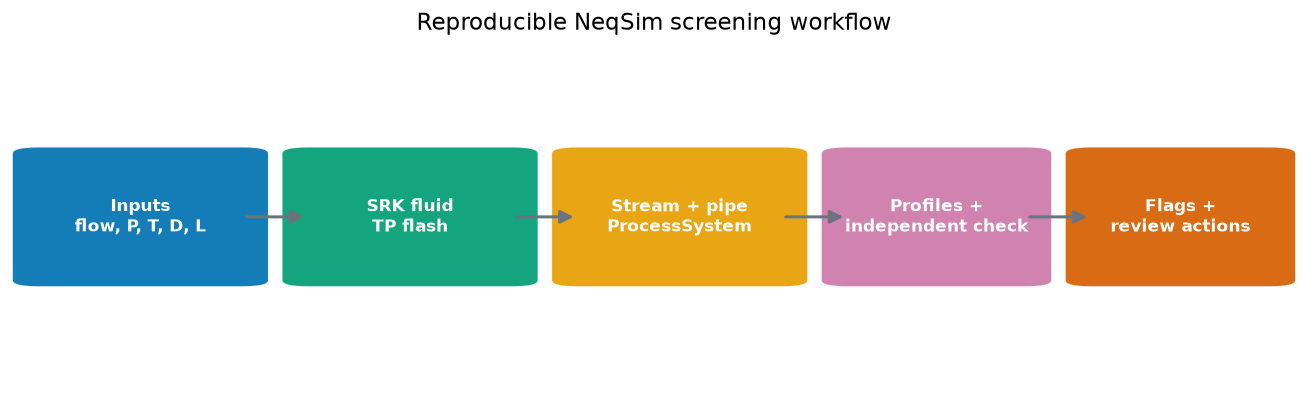

In [6]:
figure, axis = plt.subplots(figsize=(11, 3.4))
axis.set_xlim(0.0, 1.0)
axis.set_ylim(0.0, 1.0)
axis.axis("off")

workflow_nodes = [
    (0.02, 0.31, 0.16, 0.38, "Inputs\nflow, P, T, D, L", BLUE),
    (0.23, 0.31, 0.16, 0.38, "SRK fluid\nTP flash", GREEN),
    (0.44, 0.31, 0.16, 0.38, "Stream + pipe\nProcessSystem", ORANGE),
    (0.65, 0.31, 0.14, 0.38, "Profiles +\nindependent check", PURPLE),
    (0.84, 0.31, 0.14, 0.38, "Flags +\nreview actions", RED),
]

for x_position, y_position, width, height, label, color in workflow_nodes:
    box = FancyBboxPatch(
        (x_position, y_position),
        width,
        height,
        boxstyle="round,pad=0.02",
        facecolor=color,
        edgecolor="white",
        alpha=0.92,
    )
    axis.add_patch(box)
    axis.text(
        x_position + width / 2.0,
        y_position + height / 2.0,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

for start_x, end_x in [(0.18, 0.23), (0.39, 0.44), (0.60, 0.65), (0.79, 0.84)]:
    axis.add_patch(
        FancyArrowPatch(
            (start_x, 0.50),
            (end_x, 0.50),
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.8,
            color=GREY,
        )
    )

axis.set_title(
    "Reproducible NeqSim screening workflow",
    fontsize=14,
    pad=12,
)
plt.tight_layout()
plt.show()

**Figure interpretation:** the standards check is a governed chain, not a single empirical
number. Inputs, thermodynamics, equipment calculations, independent checks, and engineering
decisions remain separately inspectable.

In [7]:
PIPE_ROUGHNESS_M = 45.0e-6
VELOCITY_LIMIT_M_PER_S = 25.0
PRESSURE_LOSS_FRACTION_LIMIT = 0.10


def run_pipeline_case(case_row):
    fluid = make_gas(
        temperature_c=float(case_row["temperature_c"]),
        pressure_bara=float(case_row["pressure_bara"]),
    )
    feed = Stream(f"Case {case_row['case']} feed", fluid)
    feed.setFlowRate(float(case_row["flow_kg_per_h"]), "kg/hr")

    pipe = PipeBeggsAndBrills(
        f"Case {case_row['case']} gas line",
        feed,
    )
    pipe.setLength(float(case_row["length_m"]))
    pipe.setDiameter(float(case_row["diameter_m"]))
    pipe.setPipeWallRoughness(PIPE_ROUGHNESS_M)
    pipe.setElevation(0.0)
    pipe.setNumberOfIncrements(30)
    pipe.setRunIsothermal(True)

    process = ProcessSystem()
    process.add(feed)
    process.add(pipe)
    process.run()

    length_profile_m = np.asarray(
        list(pipe.getLengthProfile()),
        dtype=float,
    )
    pressure_profile_bara = np.asarray(
        list(pipe.getPressureProfile()),
        dtype=float,
    )
    velocity_profile_m_per_s = np.asarray(
        list(pipe.getMixtureSuperficialVelocityProfile()),
        dtype=float,
    )
    density_profile_kg_per_m3 = np.asarray(
        list(pipe.getMixtureDensityProfile()),
        dtype=float,
    )
    viscosity_profile_pa_s = (
        np.asarray(
            list(pipe.getMixtureViscosityProfile()),
            dtype=float,
        )
        * 1.0e-3
    )
    reynolds_profile = np.asarray(
        list(pipe.getMixtureReynoldsNumber()),
        dtype=float,
    )

    return {
        "process": process,
        "feed": feed,
        "pipe": pipe,
        "length_m": length_profile_m,
        "pressure_bara": pressure_profile_bara,
        "velocity_m_per_s": velocity_profile_m_per_s,
        "density_kg_per_m3": density_profile_kg_per_m3,
        "viscosity_pa_s": viscosity_profile_pa_s,
        "reynolds": reynolds_profile,
    }

In [8]:
pipeline_cases = {}

for _, case_row in cases.iterrows():
    case_name = str(case_row["case"])
    pipeline_cases[case_name] = run_pipeline_case(case_row)

print("Solved independent cases:", sorted(pipeline_cases))

Solved independent cases: ['A', 'B', 'C', 'D']


## 5. Retrieve profiles and calculate independent checks

The helper below integrates density, velocity, viscosity, and Reynolds number over length.
It also repeats the original continuity calculation at the inlet. The resulting difference
is a useful unit/API check because NeqSim's first profile point should represent the same
state.

In [9]:
def length_average(values, length_m):
    return float(np.trapezoid(values, length_m) / length_m[-1])


def summarize_pipeline_case(case_row, case_result):
    length_m = case_result["length_m"]
    density = case_result["density_kg_per_m3"]
    velocity = case_result["velocity_m_per_s"]
    viscosity = case_result["viscosity_pa_s"]
    reynolds = case_result["reynolds"]
    pressure = case_result["pressure_bara"]

    average_density = length_average(density, length_m)
    average_velocity = length_average(velocity, length_m)
    average_viscosity = length_average(viscosity, length_m)
    average_reynolds = length_average(reynolds, length_m)
    diameter_m = float(case_row["diameter_m"])
    relative_roughness = PIPE_ROUGHNESS_M / diameter_m
    haaland_term = (
        (relative_roughness / 3.7) ** 1.11
        + 6.9 / average_reynolds
    )
    darcy_friction_factor = (-1.8 * math.log10(haaland_term)) ** -2
    darcy_drop_bar = (
        darcy_friction_factor
        * float(case_row["length_m"])
        / diameter_m
        * average_density
        * average_velocity**2
        / 2.0
        / 1.0e5
    )
    neqsim_drop_bar = pressure[0] - pressure[-1]
    pipe_area_m2 = math.pi * diameter_m**2 / 4.0
    continuity_velocity = (
        float(case_row["flow_kg_per_h"])
        / 3600.0
        / density[0]
        / pipe_area_m2
    )

    return {
        "case": str(case_row["case"]),
        "inlet_pressure_bara": pressure[0],
        "outlet_pressure_bara": pressure[-1],
        "neqsim_drop_bar": neqsim_drop_bar,
        "darcy_drop_bar": darcy_drop_bar,
        "drop_fraction": neqsim_drop_bar / pressure[0],
        "maximum_velocity_m_per_s": float(velocity.max()),
        "inlet_velocity_m_per_s": float(velocity[0]),
        "continuity_velocity_m_per_s": continuity_velocity,
        "average_density_kg_per_m3": average_density,
        "average_viscosity_pa_s": average_viscosity,
        "average_reynolds": average_reynolds,
        "darcy_friction_factor": darcy_friction_factor,
        "mass_residual_kg_per_h": (
            case_result["feed"].getFlowRate("kg/hr")
            - case_result["pipe"].getOutletStream().getFlowRate("kg/hr")
        ),
    }

In [10]:
summary_rows = []

for _, case_row in cases.iterrows():
    case_name = str(case_row["case"])
    summary_rows.append(
        summarize_pipeline_case(
            case_row,
            pipeline_cases[case_name],
        )
    )

pipeline_summary = pd.DataFrame(summary_rows).set_index("case")
display(
    pipeline_summary[
        [
            "outlet_pressure_bara",
            "neqsim_drop_bar",
            "darcy_drop_bar",
            "maximum_velocity_m_per_s",
            "average_reynolds",
        ]
    ].round(6)
)

,outlet_pressure_bara,neqsim_drop_bar,darcy_drop_bar,maximum_velocity_m_per_s,average_reynolds
case,,,,,
A,59.407562,0.592438,0.592912,1.454650,9.279772e+05
B,79.442499,0.557501,0.557914,1.445293,1.549692e+06
C,99.613410,0.386590,0.386851,1.226277,1.914993e+06
D,10.629694,49.370306,62.446835,65.930458,6.774426e+06


Cases A–C remain in a modest pressure-loss range. Case D loses most of its inlet pressure,
so gas expansion accelerates the outlet velocity. This is precisely where a fixed-density
estimate becomes unsuitable as a design calculation.

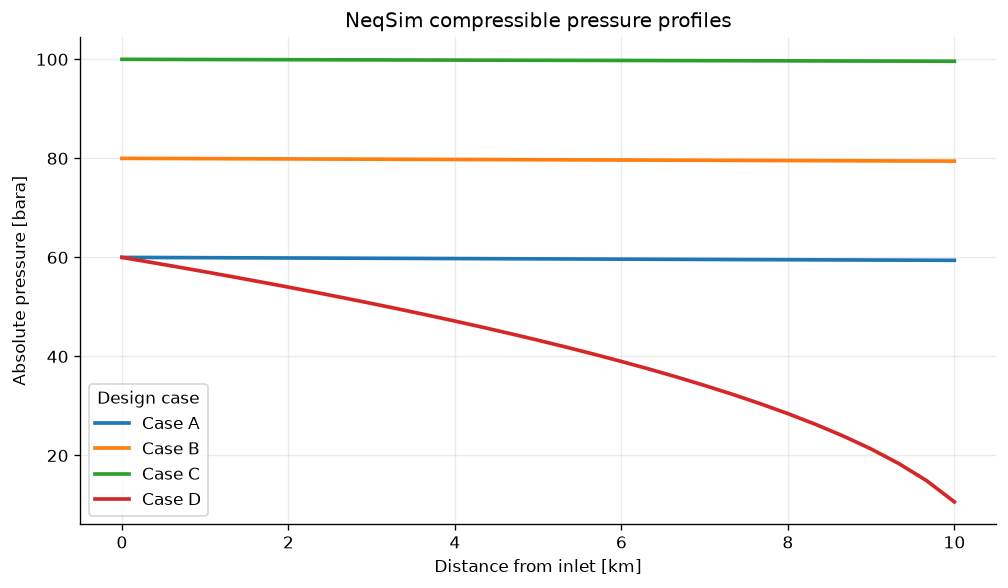

In [11]:
figure, axis = plt.subplots(figsize=(8.5, 5.0))

for case_name, case_result in pipeline_cases.items():
    axis.plot(
        case_result["length_m"] / 1000.0,
        case_result["pressure_bara"],
        linewidth=2.2,
        label=f"Case {case_name}",
    )

axis.set_xlabel("Distance from inlet [km]")
axis.set_ylabel("Absolute pressure [bara]")
axis.set_title("NeqSim compressible pressure profiles")
axis.legend(title="Design case")
plt.tight_layout()
plt.show()

**Figure interpretation:** the three original cases have nearly linear, small losses.
Case D curves as density falls, demonstrating the coupling between pressure, thermodynamic
state, and velocity.

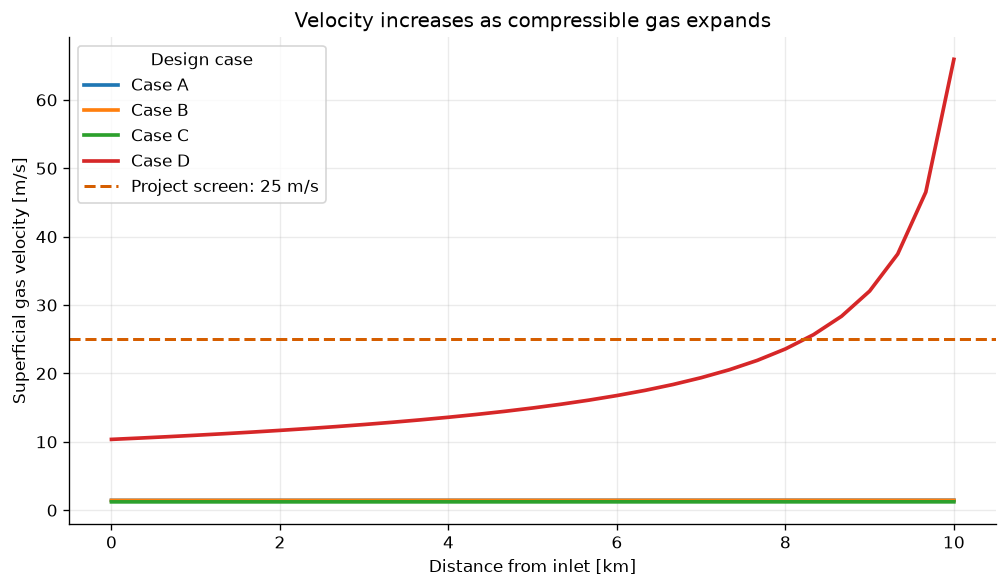

In [12]:
figure, axis = plt.subplots(figsize=(8.5, 5.0))

for case_name, case_result in pipeline_cases.items():
    axis.plot(
        case_result["length_m"] / 1000.0,
        case_result["velocity_m_per_s"],
        linewidth=2.2,
        label=f"Case {case_name}",
    )

axis.axhline(
    VELOCITY_LIMIT_M_PER_S,
    color=RED,
    linestyle="--",
    linewidth=1.8,
    label="Project screen: 25 m/s",
)
axis.set_xlabel("Distance from inlet [km]")
axis.set_ylabel("Superficial gas velocity [m/s]")
axis.set_title("Velocity increases as compressible gas expands")
axis.legend(title="Design case")
plt.tight_layout()
plt.show()

**Figure interpretation:** the original cases stay well below the example project limit.
The stressed case exceeds it near the outlet. This is a review trigger, not proof of
erosion or acceptability; noise, vibration, entrainment, solids, and project-specific
criteria require separate evaluation.

,neqsim_drop_bar,darcy_drop_bar,absolute_deviation_bar,relative_deviation_pct
case,,,,
A,0.592438,0.592912,-0.000475,-0.080073
B,0.557501,0.557914,-0.000413,-0.074048
C,0.386590,0.386851,-0.000261,-0.067514
D,49.370306,62.446835,-13.076529,-20.940259


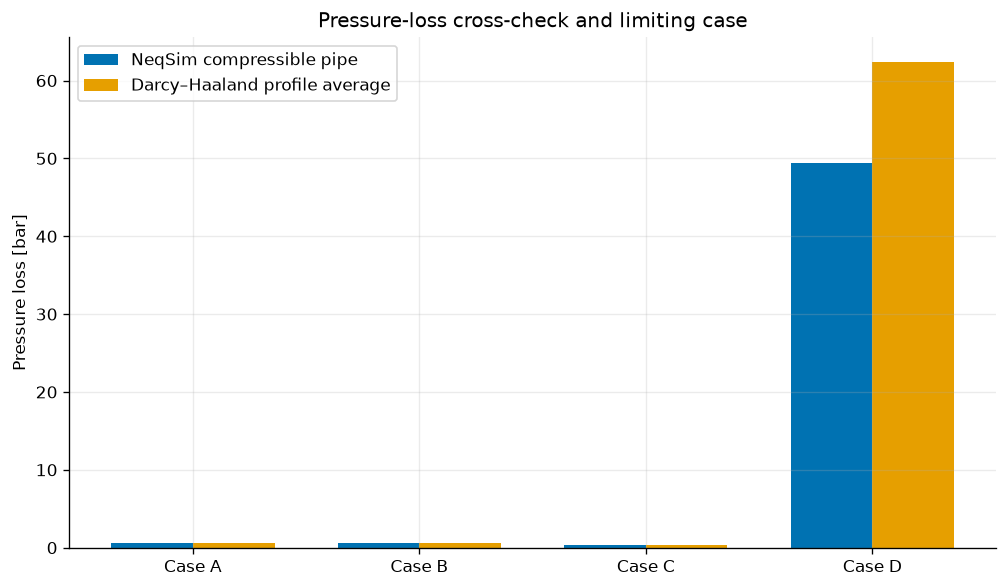

In [13]:
comparison = pipeline_summary[
    ["neqsim_drop_bar", "darcy_drop_bar"]
].copy()
comparison["absolute_deviation_bar"] = (
    comparison["neqsim_drop_bar"] - comparison["darcy_drop_bar"]
)
comparison["relative_deviation_pct"] = (
    100.0
    * comparison["absolute_deviation_bar"]
    / comparison["darcy_drop_bar"]
)
display(comparison.round(6))

figure, axis = plt.subplots(figsize=(8.5, 5.0))
x_positions = np.arange(len(comparison))
bar_width = 0.36
axis.bar(
    x_positions - bar_width / 2.0,
    comparison["neqsim_drop_bar"],
    bar_width,
    color=BLUE,
    label="NeqSim compressible pipe",
)
axis.bar(
    x_positions + bar_width / 2.0,
    comparison["darcy_drop_bar"],
    bar_width,
    color=ORANGE,
    label="Darcy–Haaland profile average",
)
axis.set_xticks(x_positions, [f"Case {name}" for name in comparison.index])
axis.set_ylabel("Pressure loss [bar]")
axis.set_title("Pressure-loss cross-check and limiting case")
axis.legend()
plt.tight_layout()
plt.show()

**Figure interpretation:** the independent calculation closely reproduces low-loss cases.
Its deviation in case D is expected because one profile average cannot fully represent a
strongly expanding gas. The disagreement is itself useful: it identifies where detailed
compressible modelling is necessary.

## 6. Preserve the original combined flagging example

The two limits below are explicit project screening inputs. They are not attributed to a
universal standard. A flag means "perform a documented review", not "the design fails a
code".

The pressure-loss fraction is:

$$
\phi_P = \frac{P_{\mathrm{in}} - P_{\mathrm{out}}}{P_{\mathrm{in}}}
$$

Both pressures are absolute and use the same unit, so $\phi_P$ is dimensionless.

In [14]:
checks = pipeline_summary[
    [
        "maximum_velocity_m_per_s",
        "drop_fraction",
        "neqsim_drop_bar",
        "outlet_pressure_bara",
    ]
].copy()
checks["velocity_flag"] = (
    checks["maximum_velocity_m_per_s"] > VELOCITY_LIMIT_M_PER_S
)
checks["pressure_drop_flag"] = (
    checks["drop_fraction"] > PRESSURE_LOSS_FRACTION_LIMIT
)
checks["any_flag"] = checks[
    ["velocity_flag", "pressure_drop_flag"]
].any(axis=1)
checks["review_action"] = np.where(
    checks["any_flag"],
    "Detailed hydraulic and mechanical review",
    "Retain in screening record",
)
display(checks.round(6))

,maximum_velocity_m_per_s,drop_fraction,neqsim_drop_bar,outlet_pressure_bara,velocity_flag,pressure_drop_flag,any_flag,review_action
case,,,,,,,,
A,1.454650,0.009874,0.592438,59.407562,False,False,False,Retain in screening record
B,1.445293,0.006969,0.557501,79.442499,False,False,False,Retain in screening record
C,1.226277,0.003866,0.386590,99.613410,False,False,False,Retain in screening record
D,65.930458,0.822838,49.370306,10.629694,True,True,True,Detailed hydraulic and mechanical review


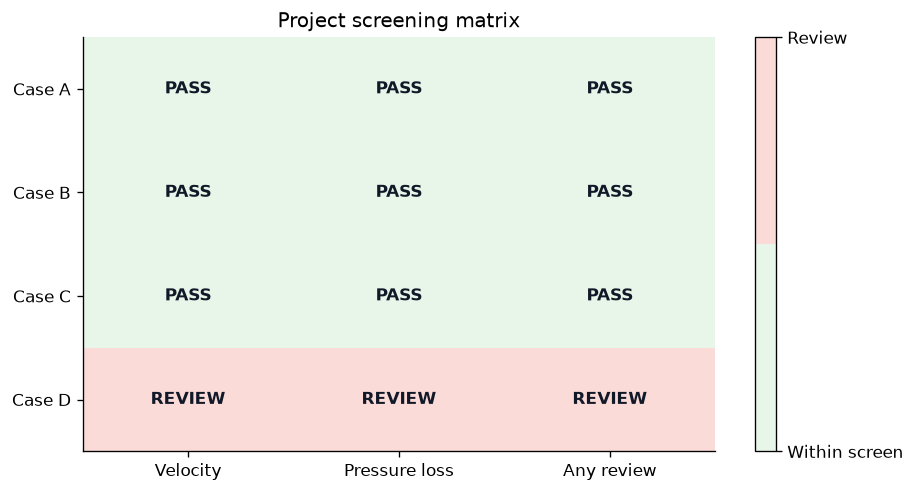

In [15]:
flag_matrix = checks[
    ["velocity_flag", "pressure_drop_flag", "any_flag"]
].astype(int)

figure, axis = plt.subplots(figsize=(7.8, 4.2))
image = axis.imshow(
    flag_matrix.to_numpy(),
    cmap=ListedColormap(["#E8F5E9", "#FADBD8"]),
    vmin=0,
    vmax=1,
    aspect="auto",
)
axis.set_xticks(
    np.arange(flag_matrix.shape[1]),
    ["Velocity", "Pressure loss", "Any review"],
)
axis.set_yticks(
    np.arange(flag_matrix.shape[0]),
    [f"Case {name}" for name in flag_matrix.index],
)

for row_index in range(flag_matrix.shape[0]):
    for column_index in range(flag_matrix.shape[1]):
        label = (
            "REVIEW"
            if flag_matrix.iloc[row_index, column_index]
            else "PASS"
        )
        axis.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontweight="bold",
            color="#111827",
        )

axis.grid(False)
axis.set_title("Project screening matrix")
colorbar = figure.colorbar(image, ax=axis, ticks=[0, 1])
colorbar.ax.set_yticklabels(["Within screen", "Review"])
plt.tight_layout()
plt.show()

**Figure interpretation:** only the deliberately stressed case triggers review. This makes
the acceptance logic visible and auditable, while keeping the engineering judgement
outside the numerical solver.

## 7. Preliminary critical gas-relief screen

A line review often sits beside relief-load review. For a perfect-gas approximation with a
real-gas compressibility correction, the critical mass flux gives:

$$
A = \frac{\dot{m}\sqrt{Z R_s T_0}}
{C_d P_0\sqrt{k\left(\frac{2}{k+1}\right)^{\frac{k+1}{k-1}}}}
$$

$A$ is effective flow area in $\mathrm{m^2}$, $Z$ is NeqSim compressibility, $R_s$ is
specific gas constant in $\mathrm{J/(kg\ K)}$, $T_0$ is upstream temperature in kelvin,
$C_d$ is an assumed discharge coefficient, $P_0$ is absolute relieving pressure in pascal,
and $k=C_p/C_v$. This simplified equation is valid only for single-phase critical gas flow.
It does not replace API 520/521 or ISO 4126 sizing, certified coefficients, backpressure
corrections, inlet-loss checks, reaction models, or two-phase methods.

In [16]:
UNIVERSAL_GAS_CONSTANT_J_PER_MOL_K = 8.314462618


def critical_gas_relief_area(
    mass_flow_kg_per_h,
    relieving_pressure_bara,
    relieving_temperature_c,
    discharge_coefficient=0.975,
):
    relieving_gas = make_gas(
        temperature_c=relieving_temperature_c,
        pressure_bara=relieving_pressure_bara,
    )
    heat_capacity_ratio = (
        relieving_gas.getCp("J/kgK")
        / relieving_gas.getCv("J/kgK")
    )
    z_factor = relieving_gas.getZ()
    molar_mass_kg_per_mol = relieving_gas.getMolarMass("kg/mol")
    specific_gas_constant = (
        UNIVERSAL_GAS_CONSTANT_J_PER_MOL_K
        / molar_mass_kg_per_mol
    )
    temperature_k = 273.15 + relieving_temperature_c
    pressure_pa = relieving_pressure_bara * 1.0e5
    mass_flow_kg_per_s = mass_flow_kg_per_h / 3600.0
    critical_flow_factor = math.sqrt(
        heat_capacity_ratio
        * (2.0 / (heat_capacity_ratio + 1.0))
        ** (
            (heat_capacity_ratio + 1.0)
            / (heat_capacity_ratio - 1.0)
        )
    )
    area_m2 = (
        mass_flow_kg_per_s
        * math.sqrt(
            z_factor
            * specific_gas_constant
            * temperature_k
        )
        / (
            discharge_coefficient
            * pressure_pa
            * critical_flow_factor
        )
    )
    equivalent_diameter_m = math.sqrt(4.0 * area_m2 / math.pi)
    critical_pressure_ratio = (
        2.0 / (heat_capacity_ratio + 1.0)
    ) ** (
        heat_capacity_ratio
        / (heat_capacity_ratio - 1.0)
    )

    return {
        "area_m2": area_m2,
        "equivalent_diameter_m": equivalent_diameter_m,
        "heat_capacity_ratio": heat_capacity_ratio,
        "z_factor": z_factor,
        "critical_pressure_ratio": critical_pressure_ratio,
    }

In [17]:
base_relief = critical_gas_relief_area(
    mass_flow_kg_per_h=12000.0,
    relieving_pressure_bara=90.0,
    relieving_temperature_c=25.0,
)
base_relief_table = pd.DataFrame(
    [
        {
            "Required effective area [mm²]": (
                base_relief["area_m2"] * 1.0e6
            ),
            "Equivalent diameter [mm]": (
                base_relief["equivalent_diameter_m"] * 1000.0
            ),
            "Heat-capacity ratio [-]": (
                base_relief["heat_capacity_ratio"]
            ),
            "Z-factor [-]": base_relief["z_factor"],
            "Critical pressure ratio [-]": (
                base_relief["critical_pressure_ratio"]
            ),
        }
    ]
)
display(base_relief_table.round(6))

,Required effective area [mm²],Equivalent diameter [mm],Heat-capacity ratio [-],Z-factor [-],Critical pressure ratio [-]
0,168.524144,14.648263,1.73428,0.815006,0.477778


The equivalent diameter is a transparent physics screen, not a selected standard orifice.
A final calculation must evaluate the actual relieving scenario and choose certified
hardware according to the adopted code edition.

In [18]:
relief_pressures_bara = np.array([50.0, 70.0, 90.0, 110.0, 130.0])
relief_rows = []

for relieving_pressure_bara in relief_pressures_bara:
    result = critical_gas_relief_area(
        mass_flow_kg_per_h=12000.0,
        relieving_pressure_bara=relieving_pressure_bara,
        relieving_temperature_c=25.0,
    )
    relief_rows.append(
        {
            "relieving_pressure_bara": relieving_pressure_bara,
            "area_mm2": result["area_m2"] * 1.0e6,
            "equivalent_diameter_mm": (
                result["equivalent_diameter_m"] * 1000.0
            ),
            "z_factor": result["z_factor"],
            "heat_capacity_ratio": result["heat_capacity_ratio"],
        }
    )

relief_sensitivity = pd.DataFrame(relief_rows)
display(relief_sensitivity.round(6))

,relieving_pressure_bara,area_mm2,equivalent_diameter_mm,z_factor,heat_capacity_ratio
0,50.0,332.727658,20.582566,0.887156,1.491745
1,70.0,226.467516,16.980795,0.847865,1.609932
2,90.0,168.524144,14.648263,0.815006,1.734280
3,110.0,133.128174,13.019372,0.790805,1.845581
4,130.0,110.159503,11.843118,0.776628,1.924613


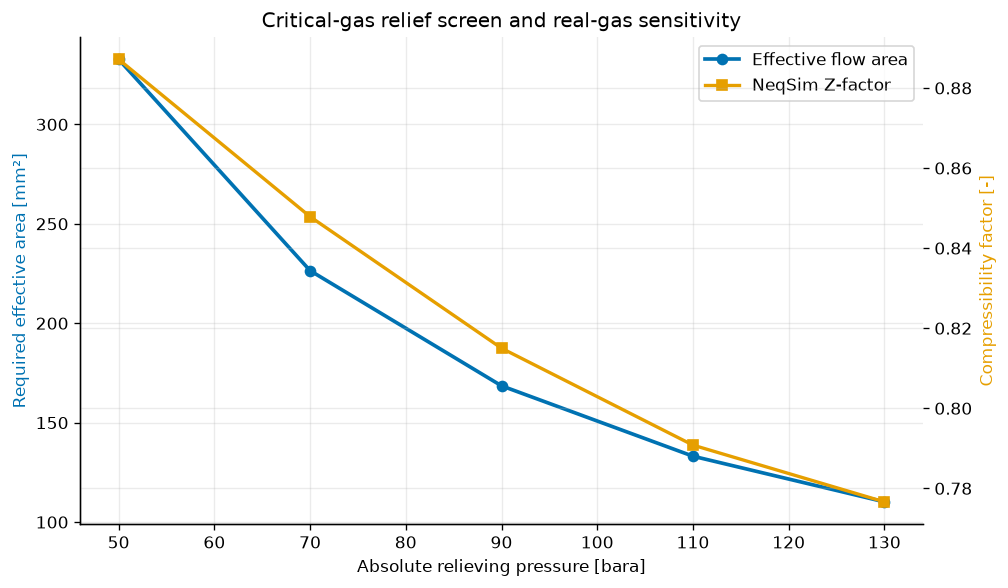

In [19]:
figure, primary_axis = plt.subplots(figsize=(8.5, 5.0))
secondary_axis = primary_axis.twinx()

area_line = primary_axis.plot(
    relief_sensitivity["relieving_pressure_bara"],
    relief_sensitivity["area_mm2"],
    color=BLUE,
    marker="o",
    linewidth=2.2,
    label="Effective flow area",
)
z_line = secondary_axis.plot(
    relief_sensitivity["relieving_pressure_bara"],
    relief_sensitivity["z_factor"],
    color=ORANGE,
    marker="s",
    linewidth=2.0,
    label="NeqSim Z-factor",
)
primary_axis.set_xlabel("Absolute relieving pressure [bara]")
primary_axis.set_ylabel("Required effective area [mm²]", color=BLUE)
secondary_axis.set_ylabel("Compressibility factor [-]", color=ORANGE)
primary_axis.set_title("Critical-gas relief screen and real-gas sensitivity")
combined_lines = area_line + z_line
primary_axis.legend(
    combined_lines,
    [line.get_label() for line in combined_lines],
    loc="upper right",
)
plt.tight_layout()
plt.show()

**Figure interpretation:** higher absolute relieving pressure increases choked mass flux,
so the preliminary area decreases for a fixed load. NeqSim simultaneously updates $Z$ and
$k$; treating them as universal constants would hide part of the real-gas response.

## 8. Final application: reusable design-window workflow

The final section applies the same NeqSim object graph to a throughput/diameter decision.
Fresh process objects are built for every diameter. The workflow returns numerical results,
checks limits, and selects the smallest candidate that passes both project screens. This is
how the notebook can be adapted to an engineering study rather than copied as isolated
calculations.

In [20]:
design_diameters_m = np.array([0.15, 0.18, 0.20, 0.22, 0.25])
design_rows = []

for diameter_m in design_diameters_m:
    design_case = pd.Series(
        {
            "case": f"Design {diameter_m:.2f} m",
            "flow_kg_per_h": 35000.0,
            "diameter_m": diameter_m,
            "pressure_bara": 60.0,
            "temperature_c": 25.0,
            "length_m": 10000.0,
        }
    )
    design_result = run_pipeline_case(design_case)
    design_summary = summarize_pipeline_case(
        design_case,
        design_result,
    )
    design_rows.append(
        {
            "diameter_m": diameter_m,
            "outlet_pressure_bara": (
                design_summary["outlet_pressure_bara"]
            ),
            "pressure_loss_fraction": (
                design_summary["drop_fraction"]
            ),
            "maximum_velocity_m_per_s": (
                design_summary["maximum_velocity_m_per_s"]
            ),
            "mass_residual_kg_per_h": (
                design_summary["mass_residual_kg_per_h"]
            ),
        }
    )

design_window = pd.DataFrame(design_rows)
design_window["velocity_pass"] = (
    design_window["maximum_velocity_m_per_s"]
    <= VELOCITY_LIMIT_M_PER_S
)
design_window["pressure_loss_pass"] = (
    design_window["pressure_loss_fraction"]
    <= PRESSURE_LOSS_FRACTION_LIMIT
)
design_window["all_screens_pass"] = design_window[
    ["velocity_pass", "pressure_loss_pass"]
].all(axis=1)
display(design_window.round(6))

,diameter_m,outlet_pressure_bara,pressure_loss_fraction,maximum_velocity_m_per_s,mass_residual_kg_per_h,velocity_pass,pressure_loss_pass,all_screens_pass
0,0.15,10.629694,0.822838,65.930458,0.0,False,False,False
1,0.18,47.488756,0.208521,9.362390,0.0,True,False,False
2,0.20,53.145922,0.114235,6.684744,0.0,True,False,False
3,0.22,55.925255,0.067912,5.215465,0.0,True,True,True
4,0.25,57.935163,0.034414,3.880312,0.0,True,True,True


In [21]:
passing_designs = design_window[
    design_window["all_screens_pass"]
].copy()

if passing_designs.empty:
    selected_design = None
    print("No candidate passes both project screens.")
else:
    selected_design = passing_designs.sort_values("diameter_m").iloc[0]
    print(
        "Smallest passing candidate: "
        f"{selected_design['diameter_m']:.2f} m, "
        f"{selected_design['outlet_pressure_bara']:.3f} bara outlet, "
        f"{selected_design['maximum_velocity_m_per_s']:.3f} m/s maximum"
    )

Smallest passing candidate: 0.22 m, 55.925 bara outlet, 5.215 m/s maximum


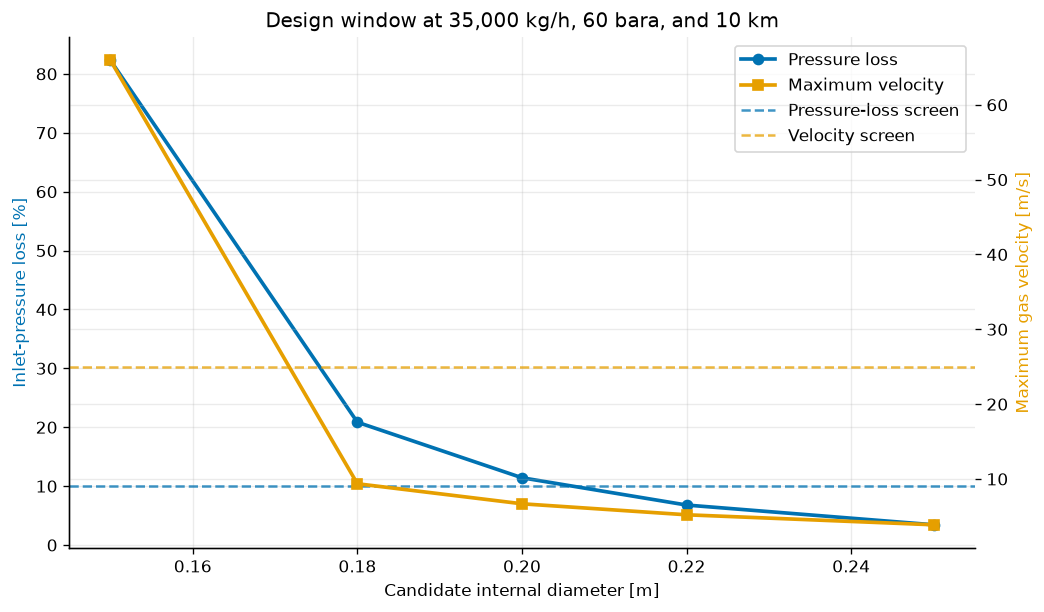

In [22]:
figure, pressure_axis = plt.subplots(figsize=(8.8, 5.2))
velocity_axis = pressure_axis.twinx()

pressure_line = pressure_axis.plot(
    design_window["diameter_m"],
    100.0 * design_window["pressure_loss_fraction"],
    color=BLUE,
    marker="o",
    linewidth=2.2,
    label="Pressure loss",
)
velocity_line = velocity_axis.plot(
    design_window["diameter_m"],
    design_window["maximum_velocity_m_per_s"],
    color=ORANGE,
    marker="s",
    linewidth=2.2,
    label="Maximum velocity",
)
pressure_limit_line = pressure_axis.axhline(
    100.0 * PRESSURE_LOSS_FRACTION_LIMIT,
    color=BLUE,
    linestyle="--",
    alpha=0.75,
    label="Pressure-loss screen",
)
velocity_limit_line = velocity_axis.axhline(
    VELOCITY_LIMIT_M_PER_S,
    color=ORANGE,
    linestyle="--",
    alpha=0.75,
    label="Velocity screen",
)
pressure_axis.set_xlabel("Candidate internal diameter [m]")
pressure_axis.set_ylabel("Inlet-pressure loss [%]", color=BLUE)
velocity_axis.set_ylabel("Maximum gas velocity [m/s]", color=ORANGE)
pressure_axis.set_title(
    "Design window at 35,000 kg/h, 60 bara, and 10 km"
)
combined_lines = (
    pressure_line
    + velocity_line
    + [pressure_limit_line, velocity_limit_line]
)
pressure_axis.legend(
    combined_lines,
    [line.get_label() for line in combined_lines],
    loc="upper right",
)
plt.tight_layout()
plt.show()

**Figure interpretation:** diameter simultaneously affects velocity and frictional loss.
The selected candidate is the smallest one in this discrete educational set that satisfies
both example screens. Economic optimization, standard pipe sizes, wall thickness, pressure
rating, surge, acoustics, and layout are intentionally outside this screening boundary.

## 9. Verification and acceptance checks

The assertions below test JSON-valid finite outputs, single-phase validity, mass closure,
continuity, low-loss benchmark agreement, limiting-case detection, relief trends, and the
existence of a passing design. They fail loudly if a future API or model change invalidates
the teaching conclusions.

In [23]:
maximum_mass_residual_kg_per_h = float(
    pipeline_summary["mass_residual_kg_per_h"].abs().max()
)
continuity_relative_residual = (
    (
        pipeline_summary["inlet_velocity_m_per_s"]
        - pipeline_summary["continuity_velocity_m_per_s"]
    ).abs()
    / pipeline_summary["continuity_velocity_m_per_s"]
)
maximum_continuity_relative_residual = float(
    continuity_relative_residual.max()
)
low_loss_deviation_pct = float(
    comparison.loc[["A", "B", "C"], "relative_deviation_pct"]
    .abs()
    .max()
)

assert np.isfinite(pipeline_summary.to_numpy()).all()
assert maximum_mass_residual_kg_per_h < 1.0e-6
assert maximum_continuity_relative_residual < 0.03
assert low_loss_deviation_pct < 1.0
assert not checks.loc[["A", "B", "C"], "any_flag"].any()
assert bool(checks.loc["D", "any_flag"])
assert relief_sensitivity["area_mm2"].is_monotonic_decreasing
assert (relief_sensitivity["area_mm2"] > 0.0).all()
assert selected_design is not None
assert design_window["mass_residual_kg_per_h"].abs().max() < 1.0e-6

validation_summary = {
    "neqsim_version": neqsim_version,
    "pipeline_cases": len(pipeline_summary),
    "maximum_mass_residual_kg_per_h": maximum_mass_residual_kg_per_h,
    "maximum_continuity_relative_residual": (
        maximum_continuity_relative_residual
    ),
    "maximum_low_loss_darcy_deviation_pct": low_loss_deviation_pct,
    "stressed_case_flagged": bool(checks.loc["D", "any_flag"]),
    "base_relief_area_mm2": base_relief["area_m2"] * 1.0e6,
    "selected_diameter_m": float(selected_design["diameter_m"]),
    "all_assertions_passed": True,
}
print(json.dumps(validation_summary, indent=2))

{
  "neqsim_version": "3.16.0",
  "pipeline_cases": 4,
  "maximum_mass_residual_kg_per_h": 0.0,
  "maximum_continuity_relative_residual": 2.102473238268579e-07,
  "maximum_low_loss_darcy_deviation_pct": 0.08007251928568093,
  "stressed_case_flagged": true,
  "base_relief_area_mm2": 168.52414388872663,
  "selected_diameter_m": 0.22,
  "all_assertions_passed": true
}


## Troubleshooting

- **The gas develops a liquid phase:** raise temperature, reduce heavy components, or use a
  multiphase design basis. Do not apply the single-phase relief equation to two-phase flow.
- **Pipe outlet pressure becomes nonphysical or the solver fails:** the candidate is outside
  a useful operating range; increase diameter, shorten the line, reduce flow, or raise
  inlet pressure before retrying.
- **Darcy and NeqSim losses disagree:** inspect density change and velocity profiles. The
  profile-average check is reliable only when compressibility effects are modest.
- **A project limit differs:** change the named constants, document the approved source and
  edition, rerun all cells, and retain the new validation evidence.
- **A component name fails:** use NeqSim database names exactly as shown in current examples.

## Practical limitations and applicability

This workflow is appropriate for early single-phase gas-line screening and method
verification. It is not a replacement for detailed network hydraulics, transient analysis,
two-phase flow assurance, piping stress, erosion/corrosion assessment, vibration/noise
review, hazardous-area design, or certified relief-device sizing.

The stressed case shows a large pressure ratio. Use a validated compressible model and
examine Mach number, temperature change, fittings, heat transfer, and choking before making
any design decision. Standards interpretation also depends on jurisdiction, adopted
edition, service, equipment category, and company requirements.

## Summary

- NeqSim supplies state-dependent density, viscosity, $Z$, $C_p$, and $C_v$.
- `Stream`, `PipeBeggsAndBrills`, and `ProcessSystem` make the screening workflow reusable.
- The original three cases pass the example project screens; the stressed case triggers a
  review and exposes the limit of a fixed-density pressure-drop estimate.
- The relief calculation demonstrates how NeqSim properties enter a transparent preliminary
  gas-flow equation without claiming standards compliance.
- Independent checks, sensitivity, stored figures, and assertions make future refreshes
  auditable.

## Further exercises

1. Add elevation and heat transfer, then compare isothermal and non-isothermal profiles.
2. Replace the synthetic gas with a documented public composition and reassess $Z$ and $k$.
3. Add fittings through an equivalent-length basis and document the source.
4. Sweep throughput and diameter on a two-dimensional grid and plot the pass region.
5. Introduce a backpressure ratio check and identify when critical flow no longer applies.
6. Connect the results to a governed JSON report with project, code edition, reviewer, and
   calculation-status fields.

## Authoritative references

- NeqSim, [Thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html).
- NeqSim, [Pipeline simulation](https://equinor.github.io/neqsim/process/equipment/pipeline_simulation).
- API, [Standards catalogue](https://www.api.org/products-and-services/standards) (including RP 14E).
- API, [Standard 520, Part I: Sizing and Selection](https://www.api.org/products-and-services/standards/important-standards-announcements/520parti).
- ISO, [ISO 4126-1:2013 Safety devices for protection against excessive pressure](https://www.iso.org/standard/50826.html).
- D. W. Brill and H. D. Beggs, *Two-Phase Flow in Pipes*, University of Tulsa, 1991.

The links identify relevant source families. Always use the edition adopted by the project
and verify access to normative text before performing a compliance calculation.